In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ravirajsinh45/real-life-industrial-dataset-of-casting-product")

print("Path to dataset files:", path)

100%|██████████| 100M/100M [00:03<00:00, 28.2MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/versions/2


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
for dirpath, dirnames, filenames in os.walk(path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 0 images in '/root/.cache/kagglehub/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/versions/2'.
There are 1 directories and 0 images in '/root/.cache/kagglehub/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/versions/2/casting_512x512'.
There are 2 directories and 0 images in '/root/.cache/kagglehub/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/versions/2/casting_512x512/casting_512x512'.
There are 0 directories and 519 images in '/root/.cache/kagglehub/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/versions/2/casting_512x512/casting_512x512/ok_front'.
There are 0 directories and 781 images in '/root/.cache/kagglehub/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/versions/2/casting_512x512/casting_512x512/def_front'.
There are 1 directories and 0 images in '/root/.cache/kagglehub/datasets/ravirajsinh45/real-life-industrial-dataset-of-castin

In [4]:
#View an image
import matplotlib.image as mpimg
import random

plt.figure(figsize=(10, 10))
def view_random_image(target_dir, target_class):
  target_folder = os.path.join(target_dir, target_class)

  random_image = random.sample(os.listdir(target_folder), 1)

  img = mpimg.imread(os.path.join(target_folder, random_image[0]))
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off")

  print(f"Image shape: {img.shape}")

  return img

<Figure size 1000x1000 with 0 Axes>

Displaying a random image from the 'ok_front' class:
Image shape: (300, 300, 3)


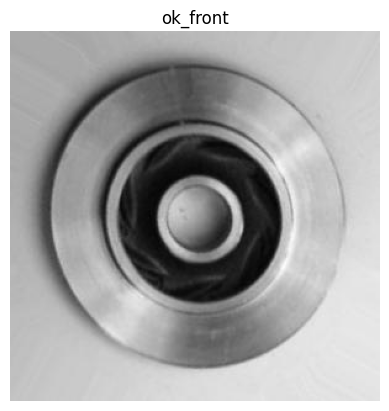

Displaying a random image from the 'def_front' class:
Image shape: (300, 300, 3)


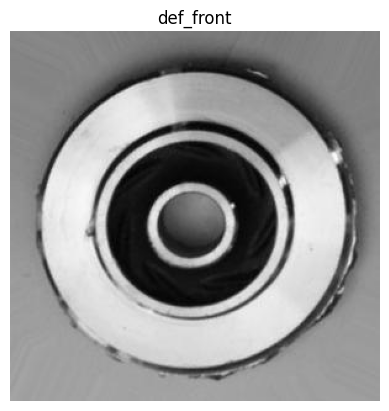

In [5]:
train_dir = "/root/.cache/kagglehub/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/versions/2/casting_data/casting_data/train"
test_dir = "/root/.cache/kagglehub/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/versions/2/casting_data/casting_data/test"

# Get the class names (subdirectories) from the train_dir
class_names = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

for class_name in class_names:
    print(f"Displaying a random image from the '{class_name}' class:")
    img = view_random_image(train_dir, class_name)
    plt.show()


In [6]:
img/255.

array([[[0.52941176, 0.52941176, 0.52941176],
        [0.52941176, 0.52941176, 0.52941176],
        [0.52941176, 0.52941176, 0.52941176],
        ...,
        [0.50588235, 0.50588235, 0.50588235],
        [0.50196078, 0.50196078, 0.50196078],
        [0.49803922, 0.49803922, 0.49803922]],

       [[0.5254902 , 0.5254902 , 0.5254902 ],
        [0.5254902 , 0.5254902 , 0.5254902 ],
        [0.52941176, 0.52941176, 0.52941176],
        ...,
        [0.50588235, 0.50588235, 0.50588235],
        [0.50196078, 0.50196078, 0.50196078],
        [0.49803922, 0.49803922, 0.49803922]],

       [[0.52156863, 0.52156863, 0.52156863],
        [0.52156863, 0.52156863, 0.52156863],
        [0.5254902 , 0.5254902 , 0.5254902 ],
        ...,
        [0.50588235, 0.50588235, 0.50588235],
        [0.50196078, 0.50196078, 0.50196078],
        [0.49803922, 0.49803922, 0.49803922]],

       ...,

       [[0.64705882, 0.64705882, 0.64705882],
        [0.64705882, 0.64705882, 0.64705882],
        [0.64313725, 0

In [7]:
IMG_SIZE = (300,300)
BATCH_SIZE = 32

The reason why img size is 300x300 and we use a single channel instead of RGB is because colors are irrelevant in the images this model is trained on.

If I wanted to check whether an apple is rotten or not, I would need to use color channels, so I would have to provide 3 (RGB) inputs. However, in this project, I am interested in the shape of the metals.

This does not worsen model training; on the contrary, by preventing unnecessary noise, it simplifies it. REMEMBER: THE SIZE OF THE MODEL DOES NOT MATTER.

In [8]:
import tensorflow as tf

In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    directory=train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=True,
    label_mode = 'binary'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    directory=test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    shuffle=False,
    label_mode = 'binary'
)

Found 6633 files belonging to 2 classes.
Found 715 files belonging to 2 classes.


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras import layers, models
model1 = models.Sequential([
    # Sigmoid Output Layer (compression between 1 and 0)
    layers.Rescaling(1./255, input_shape=(300, 300, 1)),

    # Convolutional network construction
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 2. Convolution Block 
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),


    # Classification Layer
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Binary classification
])

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 300, 300, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 298, 298, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 147, 147, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 341056)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    21,827,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,846,529 (83.34 MB)

 Trainable params: 21,846,529 (83.34 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

history = model1.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

Epoch 1/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 32s 108ms/step - accuracy: 0.7030 - loss: 0.7295 - recall: 0.5569 - val_accuracy: 0.8490 - val_loss: 0.3578 - val_recall: 0.9198
Epoch 2/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.8607 - loss: 0.3300 - recall: 0.8567 - val_accuracy: 0.8965 - val_loss: 0.2319 - val_recall: 0.9809
Epoch 3/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.9129 - loss: 0.2172 - recall: 0.9162 - val_accuracy: 0.9636 - val_loss: 0.1330 - val_recall: 0.9733
Epoch 4/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 13s 64ms/step - accuracy: 0.9594 - loss: 0.1188 - recall: 0.9638 - val_accuracy: 0.9720 - val_loss: 0.0899 - val_recall: 0.9809
Epoch 5/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step - accuracy: 0.9732 - loss: 0.0806 - recall: 0.9763 - val_accuracy: 0.9706 - val_loss: 0.0780 - val_recall: 0.9962
Epoch 6/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.9807 - loss: 0.0583 - recall: 0.9812 - val_accuracy: 0.9720 - val_loss: 0.0732 - val_recall

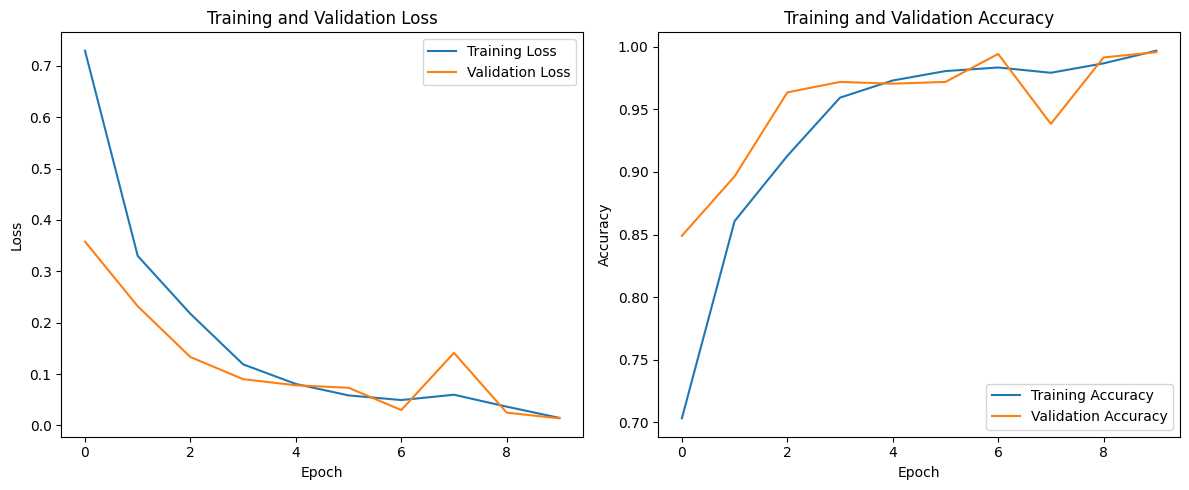

In [ ]:
# Visualize training/validation loss and accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2026-03-18 09:33:49--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-03-18 09:33:49 (115 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [22]:
from helper_functions import *


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


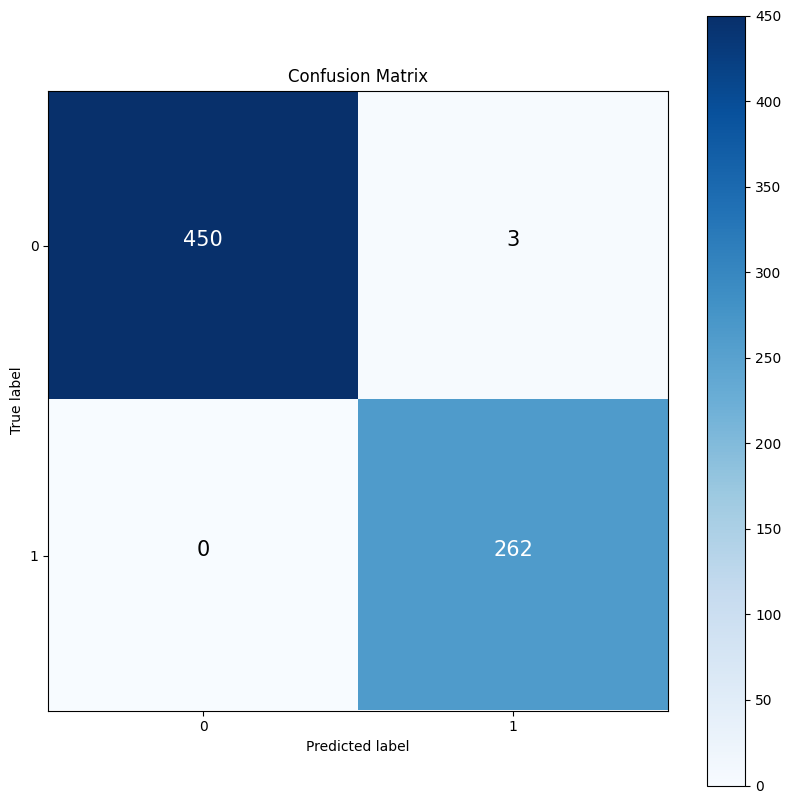

In [ ]:
# Make predictions on the test set and compare them with actual labels.
y_true_labels = np.concatenate([labels.numpy() for _, labels in test_ds], axis=0)

y_pred_probs = model1.predict(test_ds)

y_pred_binary = (y_pred_probs > 0.5).astype(int)

y_pred_binary = y_pred_binary.flatten()

make_confusion_matrix(y_true=y_true_labels, y_pred=y_pred_binary)

In [26]:
# Save model

model1.save('model1.h5')